# Conv Img Sigmentation Model
## Model that remove noice background from captcha like make mask image on the input

In [52]:
import tensorflow as tf
import glob
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir -p /content/my_dataset

In [4]:
!unzip -q /content/drive/MyDrive/ml_datasets/captcha_decoder/dataset_for_3_models.zip -d /content/my_dataset

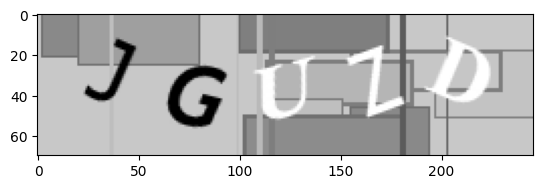

In [ ]:
image = Image.open("../dataset/model_1/images/JGUZD.png")
plt.imshow(image)

In [5]:
img_paths = sorted(glob.glob("/content/my_dataset/model_1/images/*.png"))
mask_paths = sorted(glob.glob("/content/my_dataset/model_1/masks/*.png"))

X = np.array([img_to_array(load_img(p, target_size=(64, 256))) for p in img_paths], dtype=np.float32) / 255.0
Y = np.array([img_to_array(load_img(p, target_size=(64, 256), color_mode="grayscale")) for p in mask_paths], dtype=np.float32) / 255.0

In [6]:
X[0]

array([[[0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        ...,
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374]],

       [[0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        ...,
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374]],

       [[0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        ...,
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374]],

       ...,

       [[0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0.78431374, 0.78431374],
        [0.78431374, 0

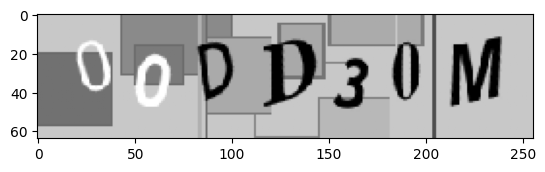

In [7]:
plt.imshow(X[0])

In [8]:
Y[0]

array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       ...,

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]], dtype=float32)

In [9]:
target_binary = Y[0].copy()
target_binary[target_binary >= 0.5] = 1.
target_binary[target_binary < 0.5] = 0.

target_binary

array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       ...,

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]], dtype=float32)

In [10]:
np.unique(target_binary)

array([0., 1.], dtype=float32)

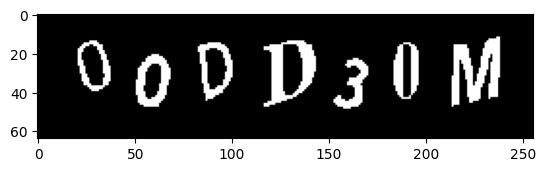

In [11]:
plt.imshow(target_binary, cmap="gray")

In [12]:
y_train = Y.copy()
y_train[y_train >= 0.5] = 1.0
y_train[y_train < 0.5] = 0.0

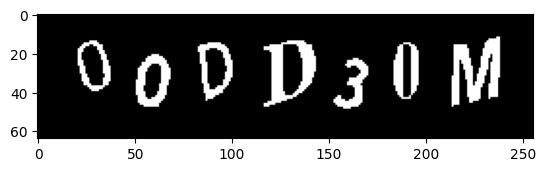

In [13]:
plt.imshow(y_train[0], cmap="gray")

## Building simplified U-NET Architecture
### Encoder

In [14]:
inp = tf.keras.layers.Input(shape=(64, 256, 3))

conv1_block1 = tf.keras.layers.Conv2D(16, kernel_size=3, activation='relu', padding='same')(inp)
conv2_block1 = tf.keras.layers.Conv2D(16, kernel_size=3, activation='relu', padding='same')(conv1_block1)
max_pool_block1 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv2_block1) # 32x128

conv1_block2 = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(max_pool_block1)
conv2_block2 = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(conv1_block2)
max_pool_block2 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv2_block2) # 16x64

### Bottleneck

In [15]:
conv1_bot = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(max_pool_block2)
conv2_bot = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(conv1_bot)

### Decoder

In [16]:
conv_trans1_block3 = tf.keras.layers.Conv2DTranspose(32, kernel_size=2, strides=2, padding='same')(conv2_bot) # 32x128
concat_block3 = tf.keras.layers.Concatenate()([conv_trans1_block3, conv2_block2]) # 32x128x32 + 32x128x32
conv1_block3 = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(concat_block3)
conv2_block3 = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(concat_block3)

conv_trans1_block4 = tf.keras.layers.Conv2DTranspose(16, kernel_size=2, strides=2, padding='same')(conv2_block3) # 64x256
concat_block4 = tf.keras.layers.Concatenate()([conv_trans1_block4, conv2_block1]) # 64x256x16 + 64x256x16
conv1_block4 = tf.keras.layers.Conv2D(16, kernel_size=3, activation='relu', padding='same')(concat_block4)
conv2_block4 = tf.keras.layers.Conv2D(16, kernel_size=3, activation='relu', padding='same')(concat_block4)

out = tf.keras.layers.Conv2D(1, kernel_size=1, activation='sigmoid', padding='same')(conv2_block4)

In [17]:
model = tf.keras.models.Model(inputs=inp, outputs=out)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 256,   │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 128,   │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 128,   │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 128,   │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 128,   │      8,224 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 128,   │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 128,   │     18,464 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 256,   │      2,064 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 256,   │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 256,   │      4,624 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 256,   │         17 │ conv2d_9[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 105,473 (412.00 KB)

 Trainable params: 105,473 (412.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
iou = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', iou])


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="drive/MyDrive/ml_models/UNET_sigmentation/best_unet_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

history = model.fit(
    X, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, checkpoint_callback]
)

Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9374 - binary_io_u: 0.3584 - loss: 0.2279
Epoch 1: val_loss improved from None to 0.04755, saving model to drive/MyDrive/ml_models/UNET_sigmentation/best_unet_model.keras

Epoch 1: finished saving model to drive/MyDrive/ml_models/UNET_sigmentation/best_unet_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.9598 - binary_io_u: 0.5993 - loss: 0.1262 - val_accuracy: 0.9812 - val_binary_io_u: 0.8050 - val_loss: 0.0475
Epoch 2/30
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9852 - binary_io_u: 0.8497 - loss: 0.0387
Epoch 2: val_loss improved from 0.04755 to 0.02857, saving model to drive/MyDrive/ml_models/UNET_sigmentation/best_unet_model.keras

Epoch 2: finished saving model to drive/MyDrive/ml_models/UNET_sigmentation/best_unet_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.9866 - binary_io_u: 0.8635 - loss: 0.0352 - val_accuracy: 0.9886 - val_binary_io_u: 0.8859 - val_l

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


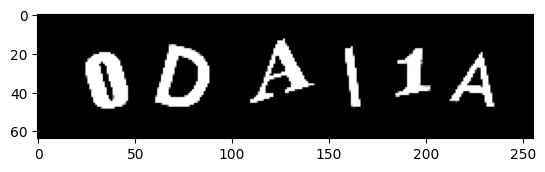

In [20]:
predicted = model.predict(X[100:101])
plt.imshow(predicted[0].squeeze(), cmap="gray")

In [21]:
model.save("drive/MyDrive/ml_models/UNET_sigmentation/best_unet_model.keras")

#### Local Test

In [53]:
def preprocesing_img(img_path):
    img = img_to_array(load_img(img_path, target_size=(64, 256))) / 255.0
    return img[np.newaxis, ...]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


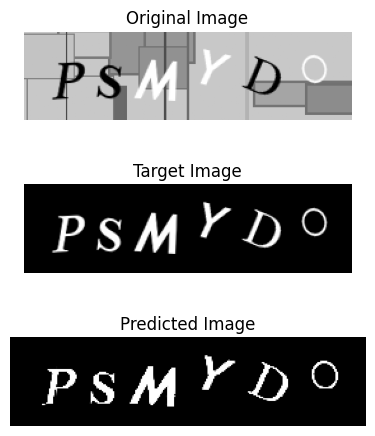

In [59]:
img_path = "../dataset/model_1/images/PSMYDO.png"
target_img_path = "../dataset/model_1/masks/PSMYDO_mask.png"

fig, ax = plt.subplots(3, 1, figsize=(10, 5))

ax[0].imshow(plt.imread(img_path))
ax[0].set_title("Original Image")

ax[1].imshow(plt.imread(target_img_path), cmap="gray")
ax[1].set_title("Target Image")

model = tf.keras.models.load_model("models/best_unet_model.keras")
y_pred = model.predict(preprocesing_img(img_path))
ax[2].imshow(y_pred[0], cmap="gray")
ax[2].set_title("Predicted Image")

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')

plt.tight_layout(pad=3.0)